In [289]:
import pandas as pd

data = pd.read_csv("/home/TE/Downloads/31116/2_dsbda/dataset.csv")

In [290]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [291]:
from sklearn.preprocessing import LabelBinarizer,LabelEncoder

bin = LabelBinarizer()
en = LabelEncoder()

In [292]:
data['race/ethnicity'].value_counts()

data['race/ethnicity'] = en.fit_transform(data['race/ethnicity'])

In [293]:
data['gender'] = bin.fit_transform(data['gender'])

In [294]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,bachelor's degree,standard,none,72,72,74
1,0,2,some college,standard,completed,69,90,88
2,0,1,master's degree,standard,none,90,95,93
3,1,0,associate's degree,free/reduced,none,47,57,44
4,1,2,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,0,4,master's degree,standard,completed,88,99,95
996,1,2,high school,free/reduced,none,62,55,55
997,0,2,high school,free/reduced,completed,59,71,65
998,0,3,some college,standard,completed,68,78,77


In [295]:
data['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [296]:
data['parental level of education'] = en.fit_transform(data['parental level of education'])

In [297]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,standard,none,72,72,74
1,0,2,4,standard,completed,69,90,88
2,0,1,3,standard,none,90,95,93
3,1,0,0,free/reduced,none,47,57,44
4,1,2,4,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,0,4,3,standard,completed,88,99,95
996,1,2,2,free/reduced,none,62,55,55
997,0,2,2,free/reduced,completed,59,71,65
998,0,3,4,standard,completed,68,78,77


In [298]:
data = data.drop(columns=['test preparation course','lunch'],axis=1)

In [299]:
data

,gender,race/ethnicity,parental level of education,math score,reading score,writing score
0,0,1,1,72,72,74
1,0,2,4,69,90,88
2,0,1,3,90,95,93
3,1,0,0,47,57,44
4,1,2,4,76,78,75
...,...,...,...,...,...,...
995,0,4,3,88,99,95
996,1,2,2,62,55,55
997,0,2,2,59,71,65
998,0,3,4,68,78,77


In [300]:
data.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [301]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

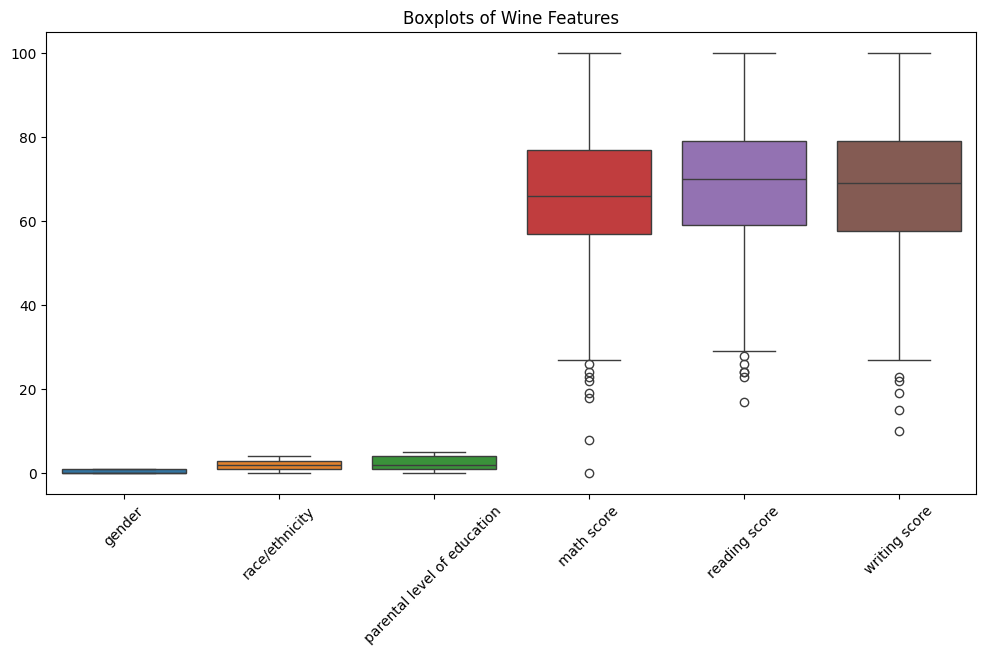

In [302]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplots of Wine Features")
plt.show()

<Axes: ylabel='writing score'>

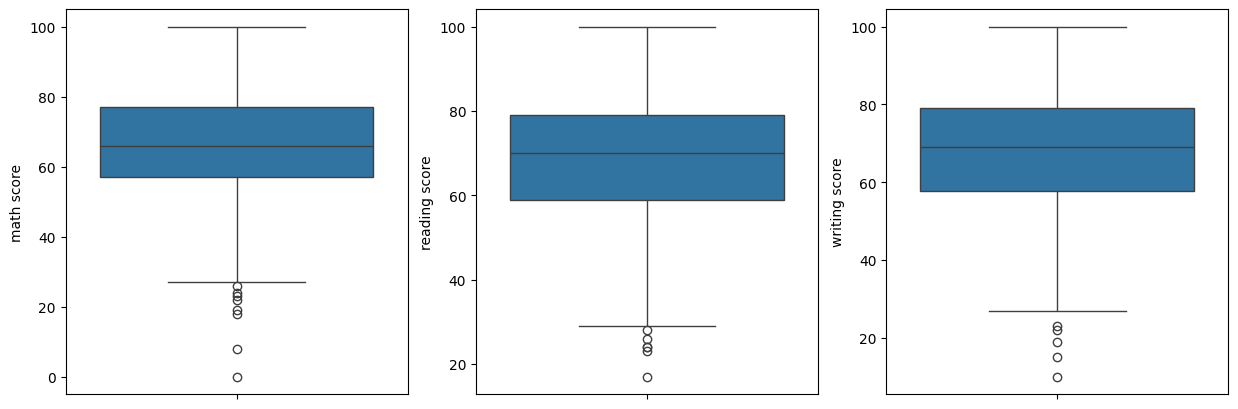

In [303]:
fig,axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(data=data['math score'],ax=axes[0])
sns.boxplot(data=data['reading score'],ax=axes[1])
sns.boxplot(data=data['writing score'],ax=axes[2])



In [304]:
from scipy import stats

z_scores = np.abs(stats.zscore(data))
outliers_z = np.where(z_scores > 3)

print("Outlier positions (row, col):")
print(list(zip(outliers_z[0][:10], outliers_z[1][:10])))


Outlier positions (row, col):
[(np.int64(17), np.int64(3)), (np.int64(59), np.int64(3)), (np.int64(59), np.int64(4)), (np.int64(59), np.int64(5)), (np.int64(76), np.int64(5)), (np.int64(327), np.int64(4)), (np.int64(327), np.int64(5)), (np.int64(596), np.int64(4)), (np.int64(596), np.int64(5)), (np.int64(787), np.int64(3))]


Dealing with outliers in reading score , writing score and math score.

In [305]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
gender                         0
race/ethnicity                 0
parental level of education    0
math score                     8
reading score                  6
writing score                  5
dtype: int64


In [306]:
def remove_outliers(feature):
    global data
    q3,q1 = np.percentile(data[feature], [75,25])
    iqr = q3-q1
    data = data[ (data[feature] <= q3 + 1.5*iqr) & (data[feature] >= q1 - 1.5*iqr) ]


In [307]:
remove_outliers('math score')
remove_outliers('reading score')
remove_outliers('writing score')

In [308]:
data

,gender,race/ethnicity,parental level of education,math score,reading score,writing score
0,0,1,1,72,72,74
1,0,2,4,69,90,88
2,0,1,3,90,95,93
3,1,0,0,47,57,44
4,1,2,4,76,78,75
...,...,...,...,...,...,...
995,0,4,3,88,99,95
996,1,2,2,62,55,55
997,0,2,2,59,71,65
998,0,3,4,68,78,77


In [309]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
gender                         0
race/ethnicity                 0
parental level of education    0
math score                     0
reading score                  0
writing score                  0
dtype: int64


<Axes: ylabel='writing score'>

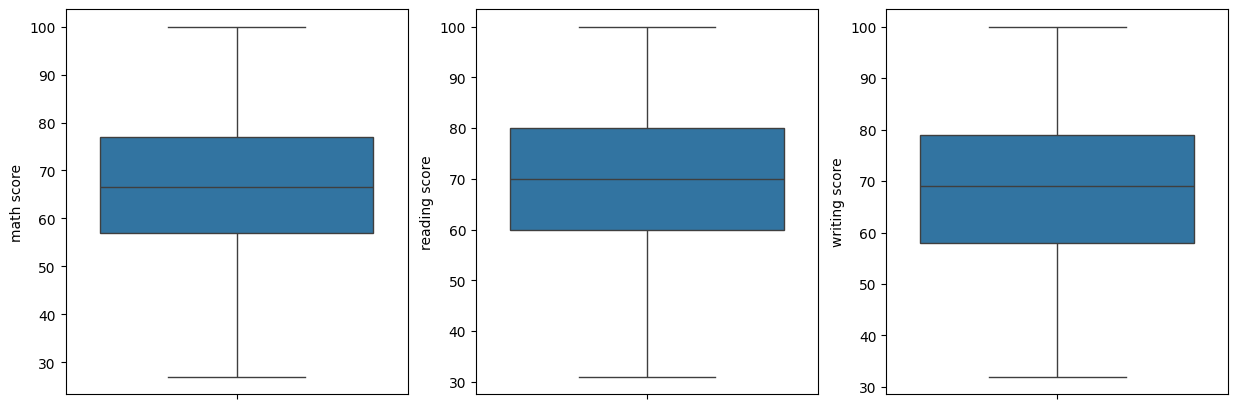

In [310]:
fig,axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(data=data['math score'],ax=axes[0])
sns.boxplot(data=data['reading score'],ax=axes[1])
sns.boxplot(data=data['writing score'],ax=axes[2])

In [311]:
from sklearn.preprocessing import StandardScaler


In [312]:
mnmax = StandardScaler()

# data['math score'] = pd.to_numeric(data['math score'])
# # .astype(float)
# data

In [313]:
# data['math score'] = mnmax.fit_transform('math score')
print(data.dtypes)


gender                         int64
race/ethnicity                 int64
parental level of education    int64
math score                     int64
reading score                  int64
writing score                  int64
dtype: object
